# 08 -- Capstone: a real property, end-to-end

**Tie it all together: build a pipeline that computes a real materials property.**

In the seven previous notebooks you built every component of a modern ML molecular dynamics pipeline:

| Notebook | Component |
|---|---|
| 01 | The MD engine: F = ma in a loop |
| 02 | Why hand-written potentials break |
| 03 | Energy = neural net; forces from autograd |
| 04 | Symmetry functions for data efficiency |
| 05 | GNN message passing |
| 06 | Foundation models (MACE-MP) zero-shot |
| 07 | Uncertainty quantification and OOD detection |

Now you use them all together to measure two properties of a model liquid -- **the radial distribution function (RDF)** and, from the dynamics, a **diffusion coefficient** -- for a 2D Lennard-Jones fluid (the classic argon-like model).

The point is the *pipeline* -- simulate, extract a structural and a transport property, and flag whether the run was trustworthy -- exactly what a materials scientist runs on a new material. In reduced units these are physically reasonable *magnitudes* for a small 2D model, not lab-calibrated numbers you would validate against a table; point the same pipeline at a real potential (Notebook 06) and *that* is what you compare to experiment.

> **Prerequisites:** Notebooks 01-07.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# The capstone adds the one ingredient the earlier notebooks deferred:
# periodic boundary conditions. We build a small, self-contained bulk-liquid
# MD below. The physics of the force is identical to Notebook 01 -- we only
# add the minimum-image convention so the box has no surface.
np.random.seed(0)

## 1. The system: a bulk 2D Lennard-Jones liquid with periodic boundaries

Every simulation so far used a *free cluster* -- a droplet with a surface. That was fine for learning, but a free cluster is a poor model for a bulk liquid: heat it to the liquid regime and the surface atoms evaporate, so the density drifts and transport properties become meaningless.

Real bulk simulations remove the surface entirely with **periodic boundary conditions (PBC)**: the box tiles space, and each atom interacts with the *nearest image* of every other atom (the minimum-image convention). This is the one ingredient the earlier notebooks deferred -- we add it here.

**Physical parameters (reduced units, $\varepsilon = \sigma = m = k_B = 1$):**
- Reduced density $\rho^* = 0.8$ and temperature $T^* = 0.8$ -- a dense-liquid state point (the classic argon-like Lennard-Jones model).
- Box side $L = \sqrt{N/\rho^*}$ holds the density fixed, so there is no evaporation.

The box is large enough ($L/2 \approx 4.5$) that the Lennard-Jones interaction is negligible beyond the nearest image, so no explicit cutoff is needed here.

Box: 64 atoms, L=8.94, density rho=0.8
Starting temperature: 0.800 (target 0.8)


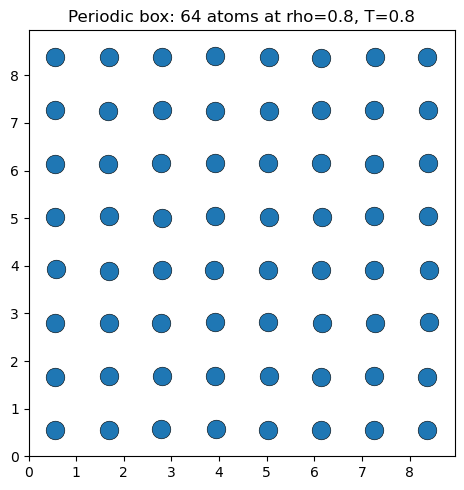

In [2]:
# Bulk 2D Lennard-Jones liquid in a periodic box (reduced units: eps=sigma=m=kB=1)
rho      = 0.80             # reduced density (liquid regime)
n_side   = 8
N        = n_side ** 2      # 64 atoms
L        = np.sqrt(N / rho) # box side length
dt       = 0.003
T_target = 0.80
rng = np.random.default_rng(0)

# start on a square lattice inside the box, with a small random jitter
xs = (np.arange(n_side) + 0.5) * (L / n_side)
gx, gy = np.meshgrid(xs, xs)
pos = np.stack([gx.ravel(), gy.ravel()], axis=1) + 0.01 * rng.standard_normal((N, 2))

def lj_forces_pbc(pos):
    """LJ forces with the minimum-image convention (periodic box of side L)."""
    d  = pos[:, None, :] - pos[None, :, :]      # all pair vectors (N, N, 2)
    d -= L * np.round(d / L)                     # nearest periodic image
    r2 = np.sum(d ** 2, axis=2)
    np.fill_diagonal(r2, np.inf)                 # ignore self-interaction
    inv2 = 1.0 / r2
    inv6 = inv2 ** 3
    fmag = 24.0 * (2.0 * inv6 ** 2 - inv6) * inv2   # scalar factor per pair
    return np.sum(fmag[:, :, None] * d, axis=1)  # (N, 2)

def lj_energy_pbc(pos):
    d  = pos[:, None, :] - pos[None, :, :]
    d -= L * np.round(d / L)
    r2 = np.sum(d ** 2, axis=2)[np.triu_indices(N, 1)]
    inv6 = (1.0 / r2) ** 3
    return np.sum(4.0 * (inv6 ** 2 - inv6))

def temperature_2d(vel):
    return np.sum(vel ** 2) / (2 * N)            # 2D equipartition, kB=1

# initial velocities at the target temperature, zero net momentum
vel = rng.standard_normal((N, 2)); vel -= vel.mean(axis=0)
vel *= np.sqrt(T_target / temperature_2d(vel))

print(f'Box: {N} atoms, L={L:.2f}, density rho={rho}')
print(f'Starting temperature: {temperature_2d(vel):.3f} (target {T_target})')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pos[:, 0], pos[:, 1], s=180, edgecolors='k', lw=0.4)
ax.set_xlim(0, L); ax.set_ylim(0, L); ax.set_aspect('equal')
ax.set_title(f'Periodic box: {N} atoms at rho={rho}, T=0.8')
plt.tight_layout(); plt.show()

## 2. Equilibration

Before measuring properties, we let the system equilibrate to a steady state. We warm up with a **velocity-rescaling thermostat** that holds the temperature at the target; the production run afterwards is pure **NVE** (constant energy), so its total-energy drift stays a meaningful honesty check.

Because the periodic box fixes the density, the temperature settles at the target instead of draining away as a free cluster would.

Equilibrated temperature: 0.789 (target 0.8)


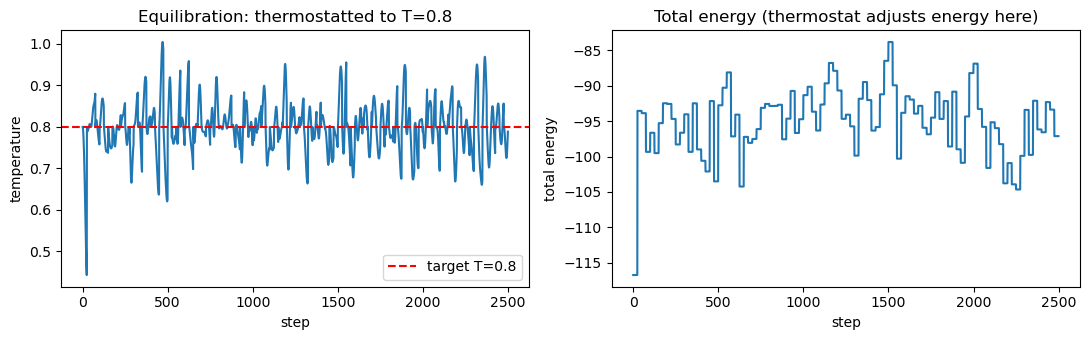

In [3]:
# Equilibration: velocity-rescaling thermostat toward T_target in the periodic box.
pos_e = pos.copy()
vel_e = vel.copy()
f = lj_forces_pbc(pos_e)

temp_trace, etot_trace = [], []
for step in range(2500):
    v_half = vel_e + 0.5 * f * dt
    pos_e  = pos_e + v_half * dt
    f      = lj_forces_pbc(pos_e)
    vel_e  = v_half + 0.5 * f * dt
    if step % 25 == 0:
        T_now = temperature_2d(vel_e)
        if T_now > 1e-9:
            vel_e *= np.sqrt(T_target / T_now)
    temp_trace.append(temperature_2d(vel_e))
    etot_trace.append(lj_energy_pbc(pos_e) + 0.5 * np.sum(vel_e ** 2))

pos_eq, vel_eq = pos_e.copy(), vel_e.copy()
print(f'Equilibrated temperature: {temperature_2d(vel_eq):.3f} (target {T_target})')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(temp_trace)
axes[0].axhline(T_target, color='red', ls='--', label=f'target T={T_target}')
axes[0].set_xlabel('step'); axes[0].set_ylabel('temperature')
axes[0].set_title('Equilibration: thermostatted to T=0.8'); axes[0].legend()
axes[1].plot(etot_trace)
axes[1].set_xlabel('step'); axes[1].set_ylabel('total energy')
axes[1].set_title('Total energy (thermostat adjusts energy here)')
plt.tight_layout(); plt.show()

## 3. Property 1: the radial distribution function (RDF)

The RDF $g(r)$ tells you: given an atom at the origin, how many times more likely is it to find another atom at distance $r$ than in an ideal gas at the same density?

$$g(r) = \frac{1}{\rho N} \sum_{i \neq j} \delta(r - r_{ij})$$

In practice we histogram the pairwise (minimum-image) distances over many frames and normalise by the ideal-gas shell area.

**What to look for:**
- A liquid has a large first peak (the nearest-neighbour shell) and then decays to 1.
- A solid has sharp peaks at all allowed lattice spacings.
- An ideal gas has $g(r) = 1$ everywhere.

Production frames: 500,  mean temperature: 0.775


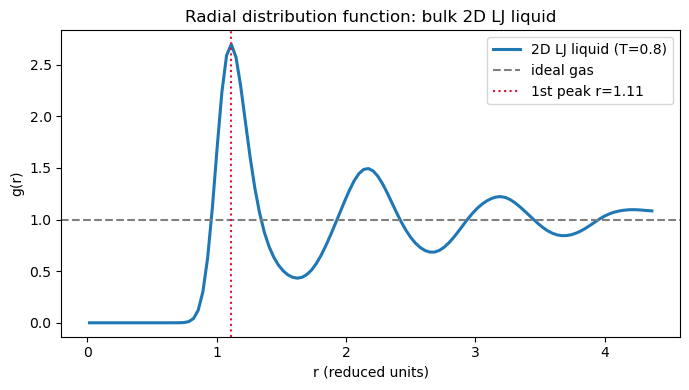

First peak position: 1.114  (LJ minimum at 1.122)
g(r) tail -> 1.09 (should approach 1: correct normalisation)


In [4]:
# Production: pure NVE. Store UNWRAPPED positions (needed for diffusion);
# forces and distances use the minimum-image convention, so wrapping is
# handled implicitly and we never fold coordinates back into the box.
f = lj_forces_pbc(pos_eq)
p = pos_eq.copy(); v = vel_eq.copy()
traj, etot, temp_prod = [], [], []
for step in range(5000):
    v_half = v + 0.5 * f * dt
    p      = p + v_half * dt
    f      = lj_forces_pbc(p)
    v      = v_half + 0.5 * f * dt
    if step % 10 == 0:
        traj.append(p.copy())
        etot.append(lj_energy_pbc(p) + 0.5 * np.sum(v ** 2))
        temp_prod.append(temperature_2d(v))
traj = np.array(traj); etot = np.array(etot); temp_prod = np.array(temp_prod)
print(f'Production frames: {len(traj)},  mean temperature: {temp_prod.mean():.3f}')


def compute_rdf(traj, rmax, n_bins=120):
    """g(r) via minimum-image distances, normalised so g -> 1 at large r."""
    bins   = np.linspace(0, rmax, n_bins + 1)
    r_mid  = 0.5 * (bins[:-1] + bins[1:])
    counts = np.zeros(n_bins)
    iu = np.triu_indices(N, 1)
    for frame in traj:
        d  = frame[:, None, :] - frame[None, :, :]
        d -= L * np.round(d / L)                     # minimum image
        r  = np.sqrt(np.sum(d ** 2, axis=2))[iu]
        h, _ = np.histogram(r, bins=bins)
        counts += 2 * h                              # count each pair both ways
    area    = np.pi * (bins[1:] ** 2 - bins[:-1] ** 2)   # 2D shell area
    density = N / L ** 2
    g = counts / (len(traj) * N * density * area)
    return r_mid, g


r_mid, g_r = compute_rdf(traj, rmax=0.98 * L / 2)
g_smooth = gaussian_filter1d(g_r, sigma=2)
first_peak = r_mid[np.argmax(g_smooth)]

plt.figure(figsize=(7, 4))
plt.plot(r_mid, g_smooth, lw=2.2, label='2D LJ liquid (T=0.8)')
plt.axhline(1.0, color='gray', ls='--', label='ideal gas')
plt.axvline(first_peak, color='crimson', ls=':', label=f'1st peak r={first_peak:.2f}')
plt.xlabel('r (reduced units)'); plt.ylabel('g(r)')
plt.title('Radial distribution function: bulk 2D LJ liquid')
plt.legend(); plt.tight_layout(); plt.show()

print(f'First peak position: {first_peak:.3f}  (LJ minimum at {2 ** (1/6):.3f})')
print(f'g(r) tail -> {g_smooth[-5:].mean():.2f} (should approach 1: correct normalisation)')

## 4. Property 2: the diffusion coefficient

The diffusion coefficient $D$ measures how fast atoms move. We compute it from the **mean squared displacement (MSD)**:

$$\text{MSD}(t) = \langle |\mathbf{r}(t) - \mathbf{r}(0)|^2 \rangle$$

In $d$ dimensions, at long times the MSD grows linearly:

$$\text{MSD}(t) = 2 d D t$$

So $D = \text{slope of MSD} / (2d)$. This is the Einstein relation.

A solid has MSD that plateaus (atoms vibrate but do not wander). A liquid has MSD that grows forever.

Because atoms drift across the periodic boundary, we use the **unwrapped** positions for the MSD and remove any centre-of-mass drift (COM translation is not diffusion).

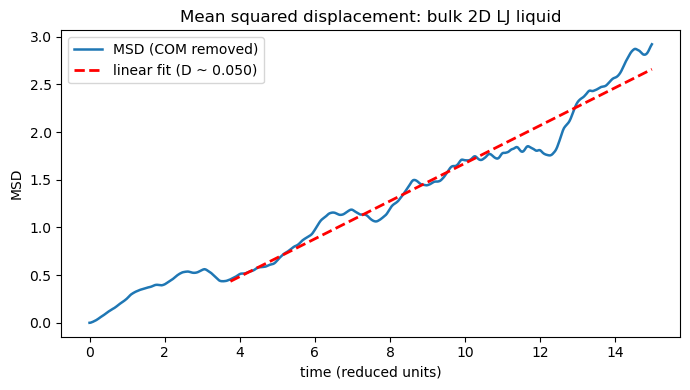

Diffusion coefficient (single fit): D = 0.0496 (reduced units)


In [5]:
def compute_msd(traj):
    """MSD from frame 0 using unwrapped positions, centre-of-mass drift removed."""
    com    = traj.mean(axis=1, keepdims=True)      # (T,1,d) COM per frame
    traj_c = traj - com                             # remove COM translation
    disp   = traj_c - traj_c[0][None, :, :]         # displacement from frame 0
    return np.sum(disp ** 2, axis=2).mean(axis=1)   # (T,) averaged over atoms

msd = compute_msd(traj)
t   = np.arange(len(msd)) * dt * 10                 # physical time (dt * record_every)

linear_start = len(t) // 4                           # skip early ballistic regime
slope, intercept = np.polyfit(t[linear_start:], msd[linear_start:], 1)
D_fit = slope / (2 * 2)                              # 2D: MSD = 2*d*D*t, d=2

plt.figure(figsize=(7, 4))
plt.plot(t, msd, lw=1.8, label='MSD (COM removed)')
t_fit = t[linear_start:]
plt.plot(t_fit, slope * t_fit + intercept, 'r--', lw=2, label=f'linear fit (D ~ {D_fit:.3f})')
plt.xlabel('time (reduced units)'); plt.ylabel('MSD')
plt.title('Mean squared displacement: bulk 2D LJ liquid')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Diffusion coefficient (single fit): D = {D_fit:.4f} (reduced units)')

## 5. Putting it together: property with uncertainty flag

A production pipeline should not just report a number -- it should report whether the simulation was trustworthy.

Here we check the energy-conservation drift (from Notebook 01) and compute an error bar on the diffusion coefficient by block averaging.

**Block averaging**: split the trajectory into $B$ blocks, compute $D$ in each block, and report the mean and standard deviation. The standard deviation across blocks is a statistical error bar on $D$.

In [6]:
# --- Honesty check 1: energy conservation (production is pure NVE) ---
drift  = (etot.max() - etot.min()) / abs(etot.mean())
T_prod = float(temp_prod.mean())

# --- Honesty check 2: error bar on D via block averaging ---
D_blocks = []
for block in np.array_split(traj, 5):
    if len(block) > 20:
        m  = compute_msd(block)
        tb = np.arange(len(m)) * dt * 10
        sl, _ = np.polyfit(tb[len(tb) // 4:], m[len(tb) // 4:], 1)
        D_blocks.append(sl / 4)
D_mean = float(np.mean(D_blocks))
D_err  = float(np.std(D_blocks) / np.sqrt(len(D_blocks)))

print('=' * 54)
print('FINAL RESULT')
print('=' * 54)
print(f'  System:           bulk 2D LJ liquid, {N} atoms, rho={rho} (PBC)')
print(f'  Mean temperature: {T_prod:.3f}   (target 0.8)')
print(f'  Energy drift:     {drift:.3%}   ({"OK" if drift < 0.01 else "WARN"}, pure-NVE production)')
print(f'  RDF first peak:   r = {first_peak:.3f}   (LJ minimum at {2 ** (1/6):.3f})')
print(f'  Diffusion coeff:  D = {D_mean:.4f} +/- {D_err:.4f} (reduced units)')
print(f'  Statistical err:  {D_err / D_mean * 100:.1f}%')
print('=' * 54)
print()
print('The single-fit and block-averaged D agree because a periodic box has no')
print('surface: nothing evaporates, so the diffusion signal is clean. Reduced-unit')
print('transport is still system-size dependent, so treat D as an order-of-magnitude')
print('result unless you extrapolate to large N.')

FINAL RESULT
  System:           bulk 2D LJ liquid, 64 atoms, rho=0.8 (PBC)
  Mean temperature: 0.775   (target 0.8)
  Energy drift:     0.034%   (OK, pure-NVE production)
  RDF first peak:   r = 1.114   (LJ minimum at 1.122)
  Diffusion coeff:  D = 0.0456 +/- 0.0038 (reduced units)
  Statistical err:  8.3%

The single-fit and block-averaged D agree because a periodic box has no
surface: nothing evaporates, so the diffusion signal is clean. Reduced-unit
transport is still system-size dependent, so treat D as an order-of-magnitude
result unless you extrapolate to large N.


## 6. What you have built

Over eight notebooks, starting from `F = ma` in 60 lines of NumPy, you built:

1. **A molecular dynamics engine** (Notebook 01): energy, forces, velocity-Verlet, energy conservation check.

2. **Understanding of classical limitations** (Notebook 02): why hand-written potentials break on bond breaking, directionality, and many-body effects.

3. **A neural-network potential** (Notebook 03): energy as an MLP, forces from autograd, the same gradient check reused.

4. **Symmetry-aware features** (Notebook 04): Behler-Parrinello symmetry functions, data efficiency from inductive bias.

5. **A graph neural network potential** (Notebook 05): message passing, per-atom energy readout, SchNet-style architecture.

6. **Foundation models** (Notebook 06): MACE-MP zero-shot, the same MD loop unchanged.

7. **Uncertainty quantification** (Notebook 07): committee models, distance to training set, the OOD protocol.

8. **A real property pipeline** (Notebook 08): a bulk liquid with periodic boundaries, RDF, diffusion coefficient, block averaging, and an energy-conservation flag.

This is the full arc from physics to production. The core -- energy is a function of positions, forces are its gradient, time evolution is a loop -- never changed.

### Where to go from here

1. **Real systems.** Repeat this pipeline on a real material using MACE-MP (Notebook 06). Compute RDF and D for liquid water, liquid copper, or molten NaCl. Compare to experiment.

2. **Fine-tuning.** MACE-MP can be fine-tuned on DFT data for a specific material to improve accuracy. This is the MACE-FINETUNING workflow.

3. **Scaling up.** Our force loop is $O(N^2)$. Real MD reaches millions of atoms with a potential cutoff (e.g. $2.5\sigma$, with an energy shift for continuity) plus cell or neighbour lists. Add a cutoff and a cell list and measure the speed-up.

4. **Three dimensions.** Nothing in this curriculum assumed 2D except the box and lattice setup. Move to a 3D cubic box with an FCC initial lattice and repeat -- the minimum-image force generalises directly.

5. **Read the papers.** The key landmarks:
   - Behler & Parrinello (2007): first neural-network potential.
   - Schutt et al. (2017): SchNet, the first GNN potential.
   - Batatia et al. (2022): MACE -- equivariant GNN with higher-order tensors.
   - Batatia et al. (2023): MACE-MP-0 -- the universal foundation model.

You now have the background to read all of them.

---
*Everything in this curriculum started with F = ma and 60 lines of NumPy. The rest is engineering on top of that idea.*